In [1]:
# Imports
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations


In [2]:
dataset_path = "/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH_Chest_Xray_Dataset/datasets/nih-chest-xrays/data/versions/3"

In [3]:
df = pd.read_csv(os.path.join(dataset_path, "Data_Entry_2017.csv"))

In [4]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [5]:
df_processed = df.copy()

In [6]:
for dirname in os.listdir(dataset_path):
    if os.path.isdir(os.path.join(dataset_path, dirname)):
        for img_name in os.listdir(os.path.join(dataset_path, dirname, "images")):
            img_path = os.path.join(dataset_path, dirname, "images", img_name)
            df_processed.loc[df_processed["Image Index"] == img_name, "Image Path"] = img_path

In [7]:
df_processed.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Image Path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...


In [8]:
old_new_columns_map = {
    'Image Index': 'image_index',
    'Finding Labels': 'finding_labels',
    'Follow-up #': 'follow_up_number',
    'Patient ID': 'patient_id',
    'Patient Age':'patient_age',
    'Patient Gender': 'patient_gender',
    'View Position': 'view_position',
    'OriginalImage[Width': 'original_image_width',
    'Height]': 'original_image_height',
    'OriginalImagePixelSpacing[x': 'original_image_pixel_spacing_x',
    'y]': 'original_image_pixel_spacing_y'
}

df_processed = df_processed.rename(columns=old_new_columns_map)

In [9]:
df_processed.head()

,image_index,finding_labels,follow_up_number,patient_id,patient_age,patient_gender,view_position,original_image_width,original_image_height,original_image_pixel_spacing_x,original_image_pixel_spacing_y,Unnamed: 11,Image Path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,/mnt/n4i_ds423/Employee_Folder/Jalil_Ahmed/NIH...


In [10]:
df_processed.drop("Unnamed: 11", axis=1, inplace=True)

In [11]:
findings = set() 
for i in df_processed['finding_labels'].unique():
    findings.update(i.split('|'))

print(f'All labels ({len(findings)}): {findings}')

All labels (15): {'Emphysema', 'Fibrosis', 'Cardiomegaly', 'Pleural_Thickening', 'No Finding', 'Infiltration', 'Atelectasis', 'Pneumonia', 'Pneumothorax', 'Hernia', 'Mass', 'Effusion', 'Consolidation', 'Nodule', 'Edema'}


In [13]:
for label in findings:
    df_processed[label] = df_processed['finding_labels'].map(lambda x: 1 if label in x else 0)

df_processed.head()

,image_index,finding_labels,follow_up_number,patient_id,patient_age,patient_gender,view_position,original_image_width,original_image_height,original_image_pixel_spacing_x,...,Infiltration,Atelectasis,Pneumonia,Pneumothorax,Hernia,Mass,Effusion,Consolidation,Nodule,Edema
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,...,0,0,0,0,0,0,0,0,0,0
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,1,0,0,0
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,0,0,0,0,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,...,0,0,0,0,1,0,0,0,0,0


In [15]:
df_processed.columns

Index(['image_index', 'finding_labels', 'follow_up_number', 'patient_id',
       'patient_age', 'patient_gender', 'view_position',
       'original_image_width', 'original_image_height',
       'original_image_pixel_spacing_x', 'original_image_pixel_spacing_y',
       'Image Path', 'Emphysema', 'Fibrosis', 'Cardiomegaly',
       'Pleural_Thickening', 'No Finding', 'Infiltration', 'Atelectasis',
       'Pneumonia', 'Pneumothorax', 'Hernia', 'Mass', 'Effusion',
       'Consolidation', 'Nodule', 'Edema'],
      dtype='object')

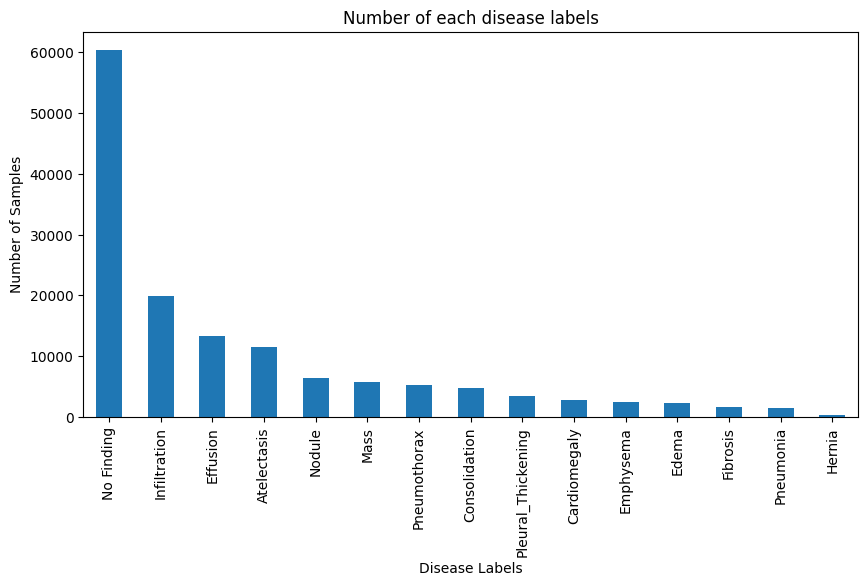

In [14]:
# Number of each disease labels 
df_processed[list(findings)].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Number of each disease labels")
plt.xlabel("Disease Labels")
plt.ylabel("Number of Samples")
plt.show()

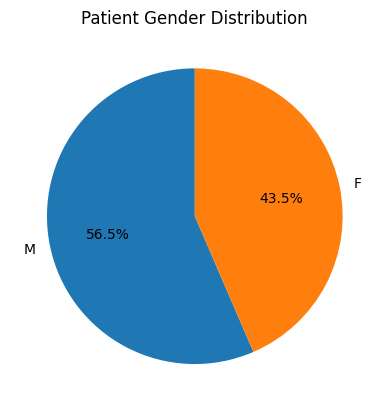

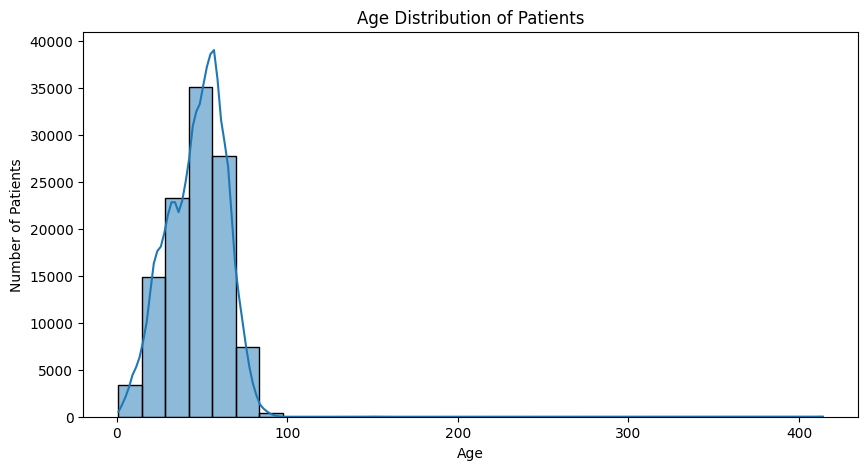

In [15]:
# Patient Demographics 
plt.pie(df_processed['patient_gender'].value_counts(), labels=df_processed['patient_gender'].value_counts().index, autopct='%1.1f%%', startangle=90)
plt.title("Patient Gender Distribution")
plt.show()

# Age of Patients 
plt.figure(figsize=(10,5))
sns.histplot(df_processed['patient_age'], bins=30, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

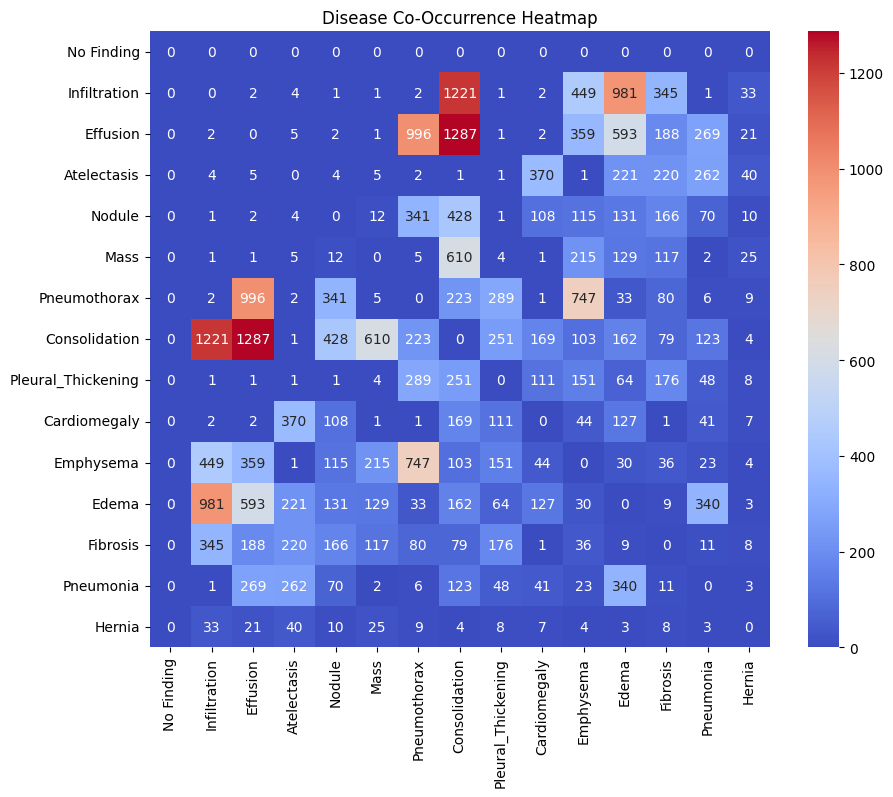

In [16]:
all_labels = [label for sublist in df_processed["finding_labels"].str.split('|') for label in sublist]  # Flatten list
label_counts = pd.Series(all_labels).value_counts()

#  Count label pairs
label_pairs = Counter()
for labels in df_processed["finding_labels"].str.split('|'):
    for combo in combinations(labels, 2):
        label_pairs[combo] += 1

co_occurrence_matrix = pd.DataFrame(0, index=label_counts.index, columns=label_counts.index)
for (label1, label2), count in label_pairs.items():
    co_occurrence_matrix.loc[label1, label2] = count
    co_occurrence_matrix.loc[label2, label1] = count

#  Plot Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(co_occurrence_matrix, cmap="coolwarm", annot=True, fmt=".0f")
plt.title("Disease Co-Occurrence Heatmap")
plt.show()

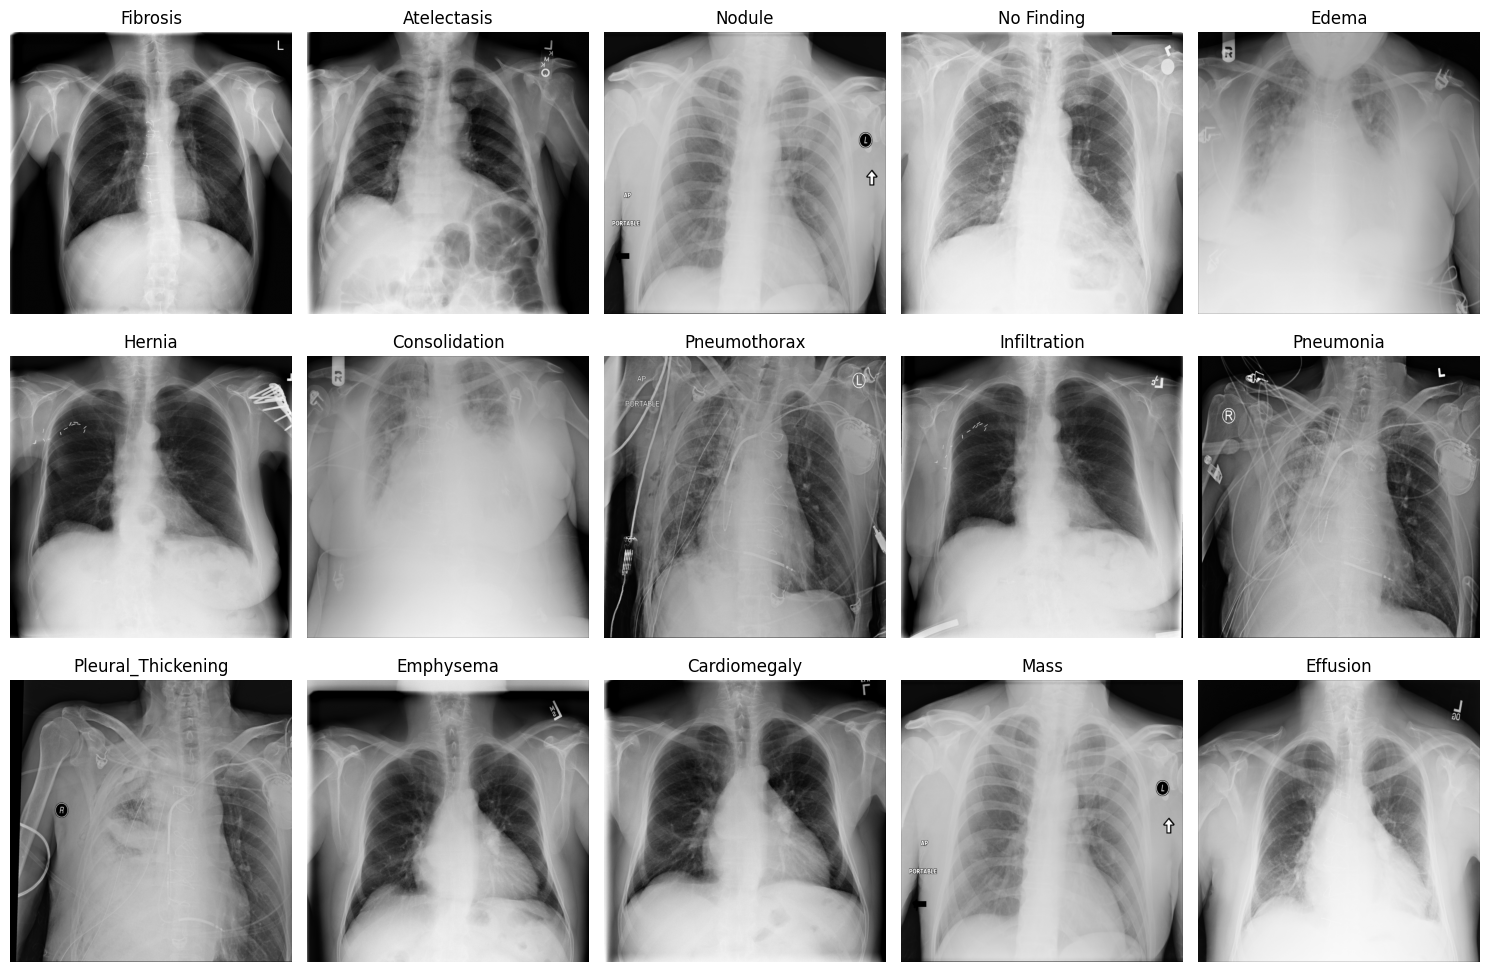

In [17]:
# Collect sample images for each disease label
sample_images = {}
for label in findings:
    sample = df_processed[df_processed[label] == 1].iloc[0]
    sample_images[label] = sample['Image Path']

# Display sample images
plt.figure(figsize=(15,10))
for i, (label, img_path) in enumerate(sample_images.items()):
    plt.subplot(3, 5, i+1)
    img = plt.imread(img_path)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

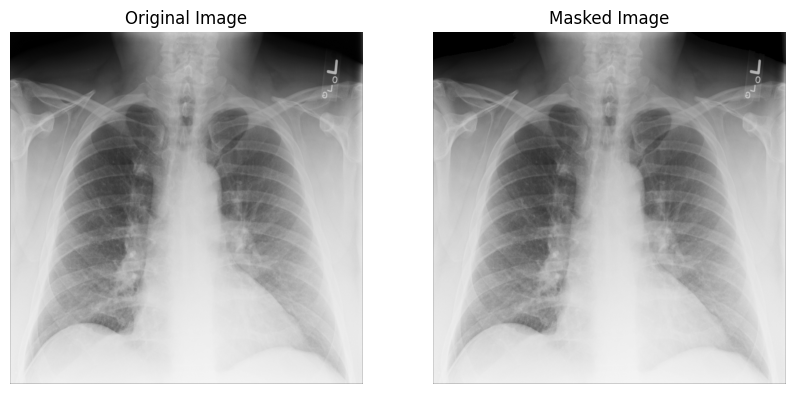

(1024, 1024) (1024, 1024)


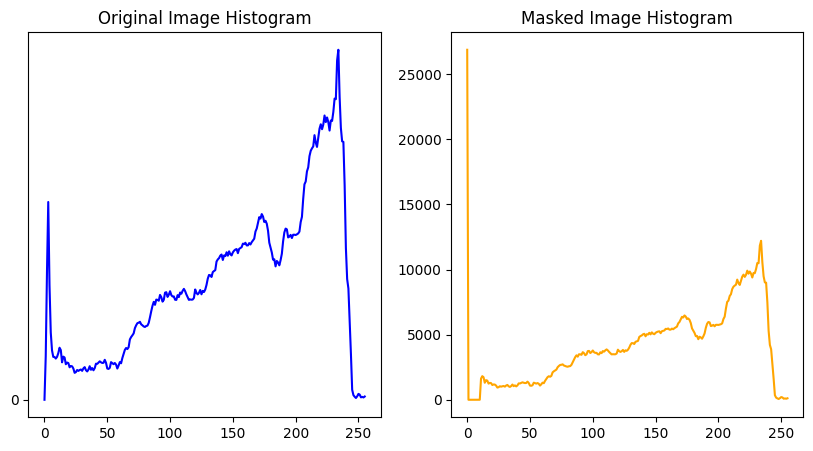

In [18]:
# Apply body mask to images (example for one image)
import cv2
import numpy as np

def apply_body_mask(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    _, thresh = cv2.threshold(image, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(image)
    cv2.drawContours(mask, contours, -1, (255), thickness=cv2.FILLED)
    masked_image = cv2.bitwise_and(image, mask)
    return masked_image

sample_image_path = df_processed.iloc[np.random.randint(0, len(df_processed))]['Image Path']

masked_image = apply_body_mask(sample_image_path)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(plt.imread(sample_image_path), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(masked_image, cmap='gray')
plt.title("Masked Image")
plt.axis('off')
plt.show()

# Check if hisotgram of both images are similar on similar scale
original_image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
print( original_image.shape, masked_image.shape)
original_hist = cv2.calcHist([original_image], [0], None, [256], [0,256])
masked_hist = cv2.calcHist([masked_image], [0], None, [256],[0,256])
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(original_hist, color='blue')
plt.yticks([0, ])
plt.title("Original Image Histogram")
plt.subplot(1,2,2)
plt.plot(masked_hist, color='orange')
plt.title("Masked Image Histogram")
plt.show() 

In [26]:
df_processed.columns

Index(['image_index', 'finding_labels', 'follow_up_number', 'patient_id',
       'patient_age', 'patient_gender', 'view_position',
       'original_image_width', 'original_image_height',
       'original_image_pixel_spacing_x', 'original_image_pixel_spacing_y',
       'Image Path', 'Fibrosis', 'Atelectasis', 'Nodule', 'No Finding',
       'Edema', 'Hernia', 'Consolidation', 'Pneumothorax', 'Infiltration',
       'Pneumonia', 'Pleural_Thickening', 'Emphysema', 'Cardiomegaly', 'Mass',
       'Effusion'],
      dtype='object')

<Axes: xlabel='original_image_width', ylabel='original_image_height'>

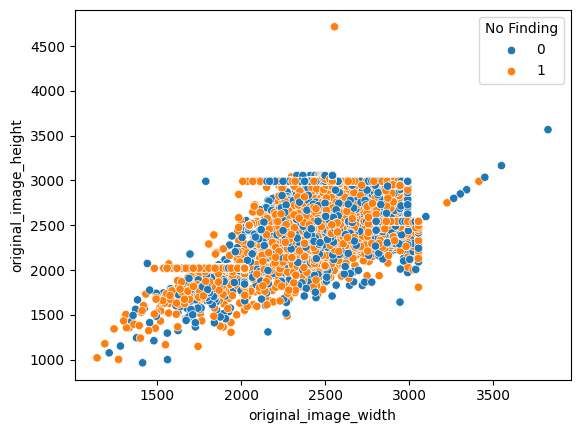

In [ ]:
# Check distribution of original image sizes
sns.scatterplot(data=df_processed, x='original_image_width', y='original_image_height', hue='No Finding')

libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


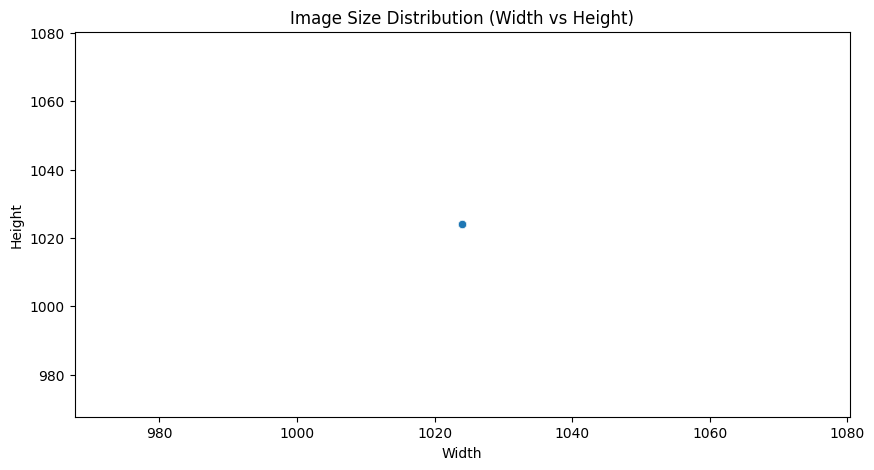

In [30]:
# Distrbution of image sizes by reading each file 
# Distrbution of image sizes by reading each flicenseile
image_sizes = []
for img_path in df_processed['Image Path']:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        image_sizes.append((img.shape[1], img.shape[0]))  # (width, height)
widths, heights = zip(*image_sizes)
plt.figure(figsize=(10,5))
sns.scatterplot(x=widths, y=heights)
plt.title("Image Size Distribution (Width vs Height)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

In [32]:
df_processed.to_csv(os.path.join(dataset_path, "processed_nih_chest_xrays.csv"), index=False)